# LLM Performance Analysis for O-RAN Intent Processing

This notebook analyzes LLM performance benchmarks across multiple models processing O-RAN network slice intents.

**Models Analyzed:**
- Claude Opus 4.5 (Anthropic)
- Gemini 3 Flash/Pro Preview (Google)
- GPT-5 / GPT-5 Nano (OpenAI)

**Metrics:**
- Token usage (input, output, reasoning)
- Response latency (GPT-5 only)
- Policy creation success rate
- Slice type categorization (eMBB, URLLC, mMTC)

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from datetime import datetime

# Enable inline plotting
%matplotlib inline

# Set consistent plot style (matching other analysis notebooks)
sns.set_theme(style='whitegrid', font_scale=1.7)

print("Libraries loaded ✓")

Libraries loaded ✓


## Configuration

In [2]:
# Data paths
RESULTS_DIR = Path("results")

# Model files to analyze
MODEL_FILES = {
    "Claude Opus 4.5": "anthropic-opus-4-5.csv",
    "Claude Sonnet 4.5": "anthropic-sonnet-4-5.csv",
    "Gemini 3 Flash": "gemini-3-flash-preview.csv",
    "Gemini 3 Pro": "gemini-3-pro-preview.csv",
    "GPT-5 Nano": "gpt-5-nano.csv",
    "GPT-5": "gpt-5.csv",
}

# Color scheme based on architecture layers (matching namespace_resources.ipynb)
# Purple for SMO/LLM, Blue for processing, Green for success, Orange for metrics
MODEL_COLORS = {
    "Claude Opus 4.5": "#B39DDB",   # Purple (Anthropic)
    "Claude Sonnet 4.5": "#CE93D8", # Light Purple (Anthropic)
    "Gemini 3 Flash": "#90CAF9",    # Light Blue (Google)
    "Gemini 3 Pro": "#64B5F6",      # Blue (Google)
    "GPT-5 Nano": "#A5D6A7",        # Light Green (OpenAI)
    "GPT-5": "#81C784",             # Green (OpenAI)
}

# Slice type classification keywords
SLICE_KEYWORDS = {
    "URLLC": ["latency", "delay", "ms", "real-time", "autonomous", "robot", "surgery", 
              "control", "industrial", "automation", "toll", "emergency"],
    "mMTC": ["sensor", "iot", "devices", "meter", "monitoring", "agriculture", 
             "parking", "smart city", "environmental"],
    "eMBB": ["video", "stream", "download", "upload", "mbps", "throughput", 
             "bandwidth", "media", "ar", "vr", "gaming", "broadcast"]
}

# Pricing per 1M tokens (USD) - January 2026
# Source: Official pricing pages for each provider
MODEL_PRICING = {
    "Claude Opus 4.5": {"input": 15.00, "output": 75.00},      # Anthropic Opus 4.5
    "Claude Sonnet 4.5": {"input": 3.00, "output": 15.00},     # Anthropic Sonnet 4.5
    "Gemini 3 Flash": {"input": 0.075, "output": 0.30},        # Google Gemini 3 Flash
    "Gemini 3 Pro": {"input": 1.25, "output": 5.00},           # Google Gemini 3 Pro
    "GPT-5 Nano": {"input": 0.15, "output": 0.60},             # OpenAI GPT-5 Nano
    "GPT-5": {"input": 2.50, "output": 10.00},                 # OpenAI GPT-5
}

print("Configuration loaded ✓")
print(f"\nModels to analyze: {list(MODEL_FILES.keys())}")

Configuration loaded ✓

Models to analyze: ['Claude Opus 4.5', 'Claude Sonnet 4.5', 'Gemini 3 Flash', 'Gemini 3 Pro', 'GPT-5 Nano', 'GPT-5']


## Data Loading and Normalization

Load CSV files and normalize column names across different providers.

In [3]:
def classify_slice_type(intent: str) -> str:
    """Classify intent into slice type based on keywords."""
    intent_lower = intent.lower()
    
    # Count keyword matches for each type
    scores = {}
    for slice_type, keywords in SLICE_KEYWORDS.items():
        scores[slice_type] = sum(1 for kw in keywords if kw in intent_lower)
    
    # Return type with highest score, default to eMBB
    if max(scores.values()) == 0:
        return "eMBB"  # Default
    return max(scores, key=scores.get)


def load_and_normalize(model_name: str, filename: str) -> pd.DataFrame:
    """Load CSV and normalize column names."""
    filepath = RESULTS_DIR / filename
    
    if not filepath.exists():
        print(f"  ✗ {model_name}: File not found")
        return pd.DataFrame()
    
    df = pd.read_csv(filepath)
    
    if df.empty or len(df) == 0:
        print(f"  ✗ {model_name}: Empty file")
        return pd.DataFrame()
    
    # Add model name
    df["model_name"] = model_name
    
    # Normalize column names based on provider
    if "anthropic" in filename:
        df = df.rename(columns={
            "usage_input_tokens": "input_tokens",
            "usage_output_tokens": "output_tokens",
            "tool_use_names": "function_call",
            "column": "response_kind",  # Sonnet CSV uses 'column' instead of 'response_kind'
        })
        df["reasoning_tokens"] = 0  # Anthropic doesn't expose reasoning tokens
        df["provider"] = "Anthropic"
        
    elif "gemini" in filename:
        df = df.rename(columns={
            "prompt_token_count": "input_tokens",
            "candidates_token_count": "output_tokens",
            "thoughts_token_count": "reasoning_tokens",
            "function_call_name": "function_call",
        })
        df["provider"] = "Google"
        df["policy_status"] = "Policy created successfully"  # Gemini files don't have this
        
    elif "gpt" in filename:
        df = df.rename(columns={
            "usage_input_tokens": "input_tokens",
            "usage_output_tokens": "output_tokens",
            "usage_output_tokens_reasoning": "reasoning_tokens",
            "function_call_name": "function_call",
        })
        df["provider"] = "OpenAI"
        
        # Calculate latency from timestamps
        if "created_at" in df.columns and "completed_at" in df.columns:
            df["created_at"] = pd.to_datetime(df["created_at"])
            df["completed_at"] = pd.to_datetime(df["completed_at"])
            df["latency_seconds"] = (df["completed_at"] - df["created_at"]).dt.total_seconds()
    
    # Classify slice type
    df["slice_type"] = df["intent"].apply(classify_slice_type)
    
    # Calculate total tokens
    df["total_tokens"] = df["input_tokens"] + df["output_tokens"] + df.get("reasoning_tokens", 0)
    
    # Calculate cost (USD)
    pricing = MODEL_PRICING.get(model_name, {"input": 0, "output": 0})
    df["cost_input"] = df["input_tokens"] * pricing["input"] / 1_000_000
    df["cost_output"] = df["output_tokens"] * pricing["output"] / 1_000_000
    df["cost_total"] = df["cost_input"] + df["cost_output"]
    
    print(f"  ✓ {model_name}: {len(df)} rows loaded")
    return df


# Load all data
print("Loading model data...")
dataframes = {}
for model_name, filename in MODEL_FILES.items():
    df = load_and_normalize(model_name, filename)
    if not df.empty:
        dataframes[model_name] = df

# Combine all data
all_data = pd.concat(dataframes.values(), ignore_index=True)
print(f"\nTotal records: {len(all_data)}")

Loading model data...
  ✓ Claude Opus 4.5: 202 rows loaded
  ✓ Claude Sonnet 4.5: 202 rows loaded
  ✓ Gemini 3 Flash: 143 rows loaded
  ✓ Gemini 3 Pro: 156 rows loaded
  ✓ GPT-5 Nano: 197 rows loaded
  ✓ GPT-5: 200 rows loaded

Total records: 1100


In [4]:
# Data summary
print("=" * 80)
print("DATA SUMMARY")
print("=" * 80)

summary = all_data.groupby("model_name").agg({
    "intent": "count",
    "input_tokens": "mean",
    "output_tokens": "mean",
    "reasoning_tokens": "mean",
}).rename(columns={"intent": "samples"})

print(summary.round(1).to_string())

print("\n" + "-" * 80)
print("Slice Type Distribution:")
print(all_data.groupby(["model_name", "slice_type"]).size().unstack(fill_value=0).to_string())

DATA SUMMARY
                   samples  input_tokens  output_tokens  reasoning_tokens
model_name                                                               
Claude Opus 4.5        202        9195.5          100.2               0.0
Claude Sonnet 4.5      202        9195.5          100.2               0.0
GPT-5                  200       13652.8          387.4             340.2
GPT-5 Nano             197       13375.0          767.7             721.2
Gemini 3 Flash         143        8125.5         1301.8            2838.6
Gemini 3 Pro           156        7612.8         1196.9            2338.9

--------------------------------------------------------------------------------
Slice Type Distribution:
slice_type         URLLC  eMBB  mMTC
model_name                          
Claude Opus 4.5      114    48    40
Claude Sonnet 4.5    114    48    40
GPT-5                114    46    40
GPT-5 Nano           113    44    40
Gemini 3 Flash        80    36    27
Gemini 3 Pro          86    4

## Plot 1: Token Usage Comparison by Model

Grouped bar chart showing mean input/output tokens per model for `intent_processing` tasks.

In [5]:
# Filter to intent_processing only (where the main work happens)
intent_data = all_data[all_data["response_kind"] == "intent_processing"].copy()

# Calculate statistics per model
token_stats = intent_data.groupby("model_name").agg({
    "input_tokens": ["mean", "std"],
    "output_tokens": ["mean", "std"],
}).round(1)

# Flatten column names
token_stats.columns = ["_".join(col) for col in token_stats.columns]
token_stats = token_stats.reset_index()

# Order models consistently
model_order = [m for m in MODEL_FILES.keys() if m in token_stats["model_name"].values]
token_stats["model_name"] = pd.Categorical(token_stats["model_name"], categories=model_order, ordered=True)
token_stats = token_stats.sort_values("model_name")

print("Token Statistics (intent_processing only):")
print(token_stats.to_string(index=False))

Token Statistics (intent_processing only):
       model_name  input_tokens_mean  input_tokens_std  output_tokens_mean  output_tokens_std
  Claude Opus 4.5            18101.4            9501.6               193.8              112.0
Claude Sonnet 4.5            18101.4            9501.6               193.8              112.0
   Gemini 3 Flash            14865.9            8347.4              2415.2             2028.3
     Gemini 3 Pro            14963.9            8175.2              2391.0             2786.8
       GPT-5 Nano            26096.7           14791.2              1190.7              375.8
            GPT-5            27045.6           15140.1               592.9              214.1


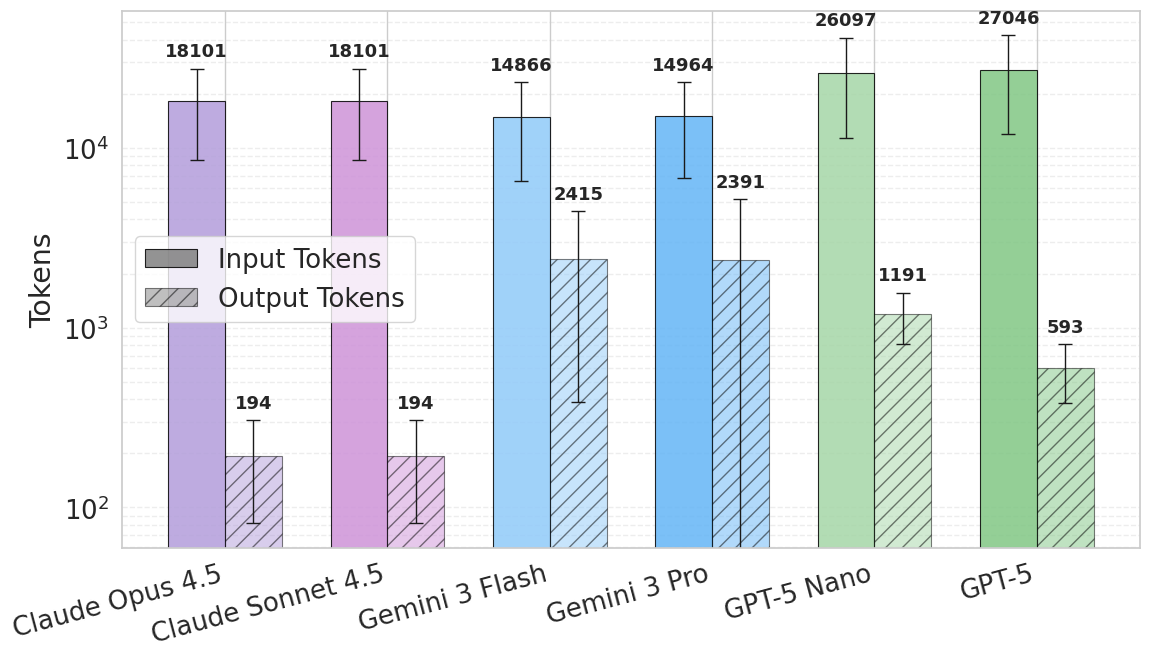


✓ Chart saved to: llm_token_usage_comparison.png


In [6]:
# Create grouped bar chart for token usage
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(token_stats))
width = 0.35

# Get colors for each model
colors = [MODEL_COLORS[m] for m in token_stats["model_name"]]

# Input tokens bars
bars1 = ax.bar(x - width/2, token_stats["input_tokens_mean"], width, 
               yerr=token_stats["input_tokens_std"], 
               label="Input Tokens", color=colors, alpha=0.85,
               edgecolor="black", linewidth=0.8,
               capsize=5, error_kw=dict(lw=1, capsize=5, capthick=1))

# Output tokens bars (darker shade)
bars2 = ax.bar(x + width/2, token_stats["output_tokens_mean"], width,
               yerr=token_stats["output_tokens_std"],
               label="Output Tokens", color=colors, alpha=0.5,
               edgecolor="black", linewidth=0.8, hatch="//",
               capsize=5, error_kw=dict(lw=1, capsize=5, capthick=1))

ax.set_ylabel("Tokens")
ax.set_xticks(x)
ax.set_xticklabels(token_stats["model_name"], rotation=15, ha="right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

# Custom legend with grey colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#808080", edgecolor="black", linewidth=0.8, alpha=0.85, label="Input Tokens"),
    Patch(facecolor="#808080", edgecolor="black", linewidth=0.8, alpha=0.5, hatch="//", label="Output Tokens"),
]
ax.legend(handles=legend_elements, loc="center left")

# Add value labels on input bars (positioned above stddev error bars)
for bar, val, std in zip(bars1, token_stats["input_tokens_mean"], token_stats["input_tokens_std"]):
    ax.annotate(f"{val:.0f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, fontweight="bold")

# Add value labels on output bars (positioned above stddev error bars)
for bar, val, std in zip(bars2, token_stats["output_tokens_mean"], token_stats["output_tokens_std"]):
    ax.annotate(f"{val:.0f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_token_usage_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_token_usage_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_token_usage_comparison.png")

## Plot 2: Token Usage by Slice Type

Compare token consumption across different slice categories (eMBB, URLLC, mMTC).

In [7]:
# Calculate tokens by slice type and model
slice_stats = intent_data.groupby(["model_name", "slice_type"]).agg({
    "input_tokens": "mean",
    "output_tokens": "mean",
    "intent": "count"
}).rename(columns={"intent": "count"}).reset_index()

# Pivot for plotting
slice_pivot = slice_stats.pivot(index="model_name", columns="slice_type", values="input_tokens")
slice_pivot = slice_pivot.reindex(model_order)

print("Input Tokens by Slice Type (mean):")
print(slice_pivot.round(0).to_string())

Input Tokens by Slice Type (mean):
slice_type           URLLC     eMBB     mMTC
model_name                                  
Claude Opus 4.5    19092.0  17622.0  15854.0
Claude Sonnet 4.5  19092.0  17622.0  15854.0
Gemini 3 Flash     14616.0  10223.0  21036.0
Gemini 3 Pro       15083.0  11602.0  19103.0
GPT-5 Nano         26323.0  18625.0  34045.0
GPT-5              27290.0  19331.0  35221.0


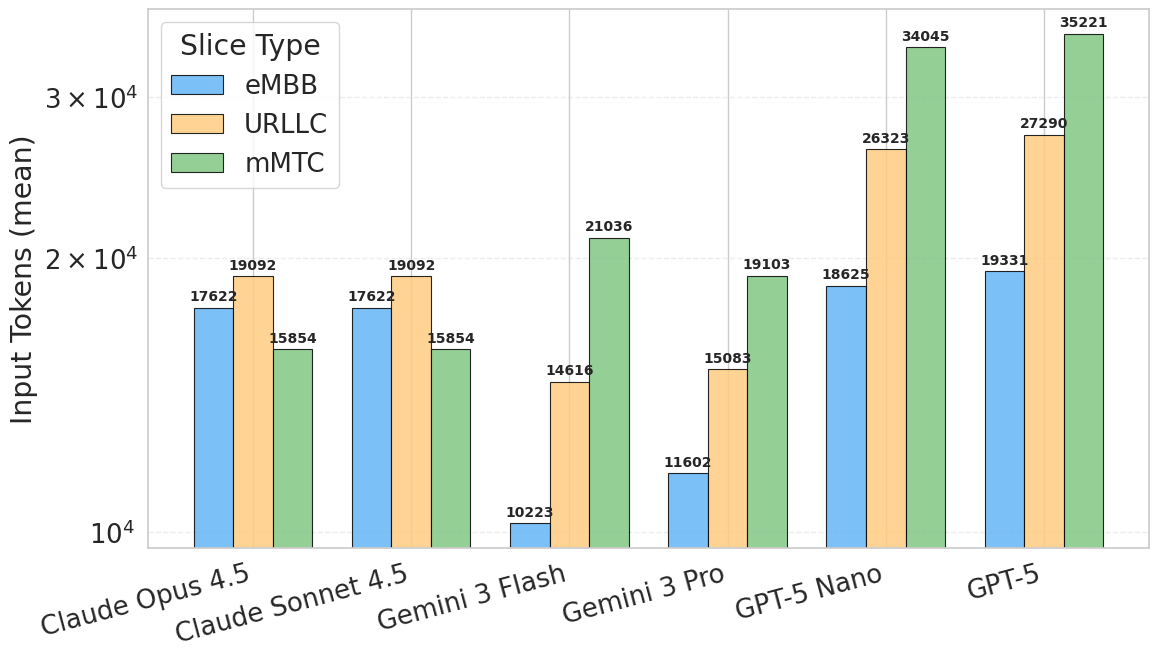


✓ Chart saved to: llm_tokens_by_slice_type.png


In [8]:
# Create grouped bar chart by slice type
fig, ax = plt.subplots(figsize=(12, 7))

slice_types = ["eMBB", "URLLC", "mMTC"]
slice_colors = {"eMBB": "#64B5F6", "URLLC": "#FFCC80", "mMTC": "#81C784"}

x = np.arange(len(slice_pivot))
width = 0.25

for i, slice_type in enumerate(slice_types):
    if slice_type in slice_pivot.columns:
        values = slice_pivot[slice_type].fillna(0).values
        bars = ax.bar(x + i*width, values, width, 
                      label=slice_type, color=slice_colors[slice_type],
                      edgecolor="black", linewidth=0.8, alpha=0.85)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax.annotate(f"{val:.0f}",
                            xy=(bar.get_x() + bar.get_width()/2, val),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Input Tokens (mean)")
ax.set_xticks(x + width)
ax.set_xticklabels(slice_pivot.index, rotation=15, ha="right")
ax.legend(title="Slice Type")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

plt.tight_layout()
plt.savefig("llm_tokens_by_slice_type.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_tokens_by_slice_type.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_tokens_by_slice_type.png")

## Plot 3: Reasoning Token Breakdown

Stacked bar chart showing input vs output vs reasoning token proportions for models that expose reasoning tokens.

In [9]:
# Filter models with reasoning tokens (Gemini and GPT-5)
reasoning_data = intent_data[intent_data["reasoning_tokens"] > 0].copy()

if len(reasoning_data) > 0:
    reasoning_stats = reasoning_data.groupby("model_name").agg({
        "input_tokens": "mean",
        "output_tokens": "mean",
        "reasoning_tokens": "mean",
    }).round(0)
    
    # Reorder
    reasoning_order = [m for m in model_order if m in reasoning_stats.index]
    reasoning_stats = reasoning_stats.reindex(reasoning_order)
    
    print("Reasoning Token Statistics:")
    print(reasoning_stats.to_string())
    
    # Calculate percentages
    reasoning_stats["total"] = reasoning_stats.sum(axis=1)
    for col in ["input_tokens", "output_tokens", "reasoning_tokens"]:
        reasoning_stats[f"{col}_pct"] = (reasoning_stats[col] / reasoning_stats["total"] * 100).round(1)
    
    print("\nPercentage breakdown:")
    print(reasoning_stats[["input_tokens_pct", "output_tokens_pct", "reasoning_tokens_pct"]].to_string())
else:
    print("No reasoning tokens found in the data.")

Reasoning Token Statistics:
                input_tokens  output_tokens  reasoning_tokens
model_name                                                   
Gemini 3 Flash       14866.0         2415.0            5015.0
Gemini 3 Pro         14964.0         2391.0            4160.0
GPT-5 Nano           26097.0         1191.0            1108.0
GPT-5                27046.0          593.0             508.0

Percentage breakdown:
                input_tokens_pct  output_tokens_pct  reasoning_tokens_pct
model_name                                                               
Gemini 3 Flash              66.7               10.8                  22.5
Gemini 3 Pro                69.6               11.1                  19.3
GPT-5 Nano                  91.9                4.2                   3.9
GPT-5                       96.1                2.1                   1.8


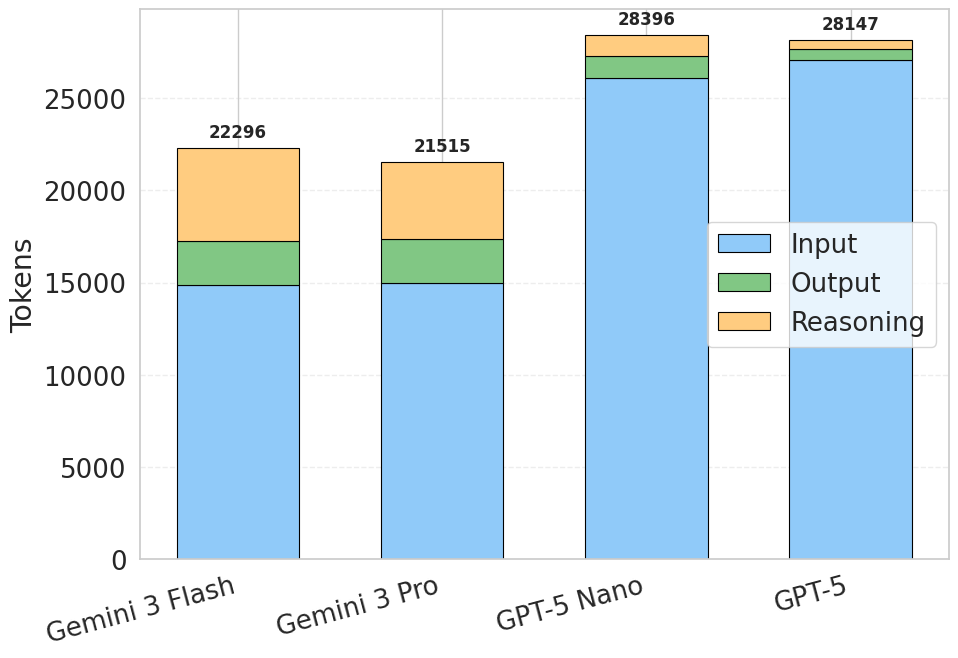


✓ Chart saved to: llm_reasoning_tokens_breakdown.png


In [10]:
# Create stacked bar chart for reasoning tokens
if len(reasoning_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    x = np.arange(len(reasoning_stats))
    width = 0.6
    
    # Stack: Input (bottom), Output (middle), Reasoning (top)
    bars1 = ax.bar(x, reasoning_stats["input_tokens"], width, 
                   label="Input", color="#90CAF9", edgecolor="black", linewidth=0.8)
    bars2 = ax.bar(x, reasoning_stats["output_tokens"], width, 
                   bottom=reasoning_stats["input_tokens"],
                   label="Output", color="#81C784", edgecolor="black", linewidth=0.8)
    bars3 = ax.bar(x, reasoning_stats["reasoning_tokens"], width,
                   bottom=reasoning_stats["input_tokens"] + reasoning_stats["output_tokens"],
                   label="Reasoning", color="#FFCC80", edgecolor="black", linewidth=0.8)
    
    ax.set_ylabel("Tokens")
    ax.set_xticks(x)
    ax.set_xticklabels(reasoning_stats.index, rotation=15, ha="right")
    ax.legend(loc="center right")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    
    # Add total labels on top
    for i, (idx, row) in enumerate(reasoning_stats.iterrows()):
        total = row["total"]
        ax.annotate(f"{total:.0f}",
                    xy=(i, total),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("llm_reasoning_tokens_breakdown.png", dpi=300, bbox_inches="tight")
    plt.savefig("llm_reasoning_tokens_breakdown.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✓ Chart saved to: llm_reasoning_tokens_breakdown.png")
else:
    print("Skipping reasoning token chart - no data available.")

## Plot 4: Response Latency (GPT-5 Only)

Box plot comparing response latency between GPT-5 and GPT-5 Nano.

In [11]:
# Filter GPT-5 models with latency data
latency_data = intent_data[intent_data["latency_seconds"].notna()].copy()

if len(latency_data) > 0:
    latency_stats = latency_data.groupby("model_name")["latency_seconds"].agg(["mean", "std", "min", "max", "count"])
    print("Latency Statistics (seconds):")
    print(latency_stats.round(2).to_string())
else:
    print("No latency data available.")

Latency Statistics (seconds):
             mean   std  min   max  count
model_name                               
GPT-5       11.24  4.65  5.0  34.0    100
GPT-5 Nano  10.52  3.35  5.0  20.0    100


/tmp/ipykernel_2714439/3119816150.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([latency_data[latency_data["model_name"] == m]["latency_seconds"] for m in latency_order],


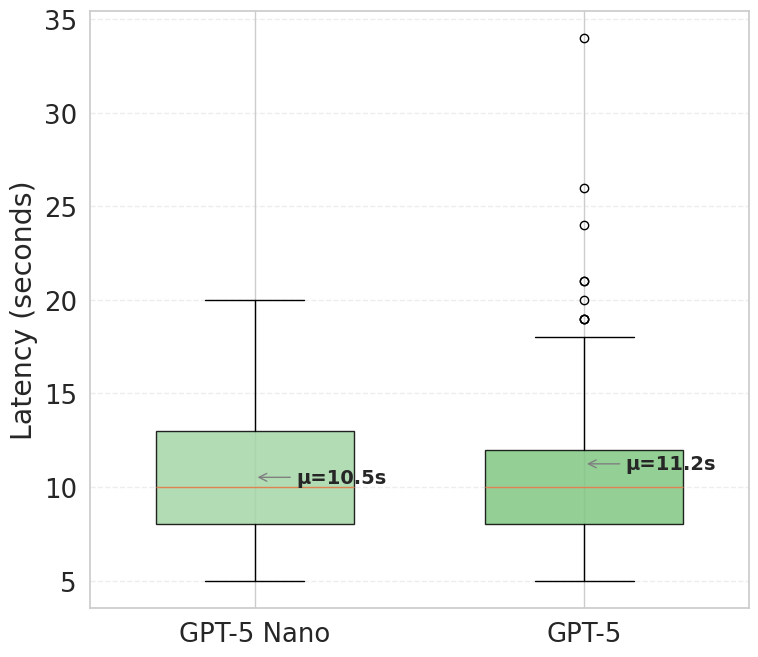


✓ Chart saved to: llm_response_latency.png


In [12]:
# Create box plot for latency
if len(latency_data) > 0:
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Order models
    latency_order = [m for m in ["GPT-5 Nano", "GPT-5"] if m in latency_data["model_name"].unique()]
    colors_lat = [MODEL_COLORS[m] for m in latency_order]
    
    # Create box plot
    bp = ax.boxplot([latency_data[latency_data["model_name"] == m]["latency_seconds"] for m in latency_order],
                    labels=latency_order, patch_artist=True, widths=0.6)
    
    # Color boxes
    for patch, color in zip(bp["boxes"], colors_lat):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor("black")
    
    ax.set_ylabel("Latency (seconds)")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    
    # Add mean values
    for i, model in enumerate(latency_order):
        mean_val = latency_data[latency_data["model_name"] == model]["latency_seconds"].mean()
        ax.annotate(f"μ={mean_val:.1f}s",
                    xy=(i+1, mean_val),
                    xytext=(30, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=14, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color="gray"))
    
    plt.tight_layout()
    plt.savefig("llm_response_latency.png", dpi=300, bbox_inches="tight")
    plt.savefig("llm_response_latency.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✓ Chart saved to: llm_response_latency.png")
else:
    print("Skipping latency chart - no data available.")

## Plot 5: Policy Success Rate

Horizontal bar chart comparing policy creation success rates by model.

In [13]:
# Calculate success rates
success_data = intent_data[intent_data["policy_status"].notna()].copy()

if len(success_data) > 0:
    success_data["success"] = success_data["policy_status"].str.contains("success", case=False, na=False)
    
    success_stats = success_data.groupby("model_name").agg({
        "success": ["sum", "count"]
    })
    success_stats.columns = ["successes", "total"]
    success_stats["success_rate"] = (success_stats["successes"] / success_stats["total"] * 100).round(1)
    
    # Reorder
    success_order = [m for m in model_order if m in success_stats.index]
    success_stats = success_stats.reindex(success_order)
    
    print("Policy Success Rates:")
    print(success_stats.to_string())
else:
    print("No policy status data available.")

Policy Success Rates:
                   successes  total  success_rate
model_name                                       
Claude Opus 4.5          101    101         100.0
Claude Sonnet 4.5        101    101         100.0
Gemini 3 Flash            77     77         100.0
Gemini 3 Pro              78     78         100.0
GPT-5 Nano                97     97         100.0
GPT-5                    100    100         100.0


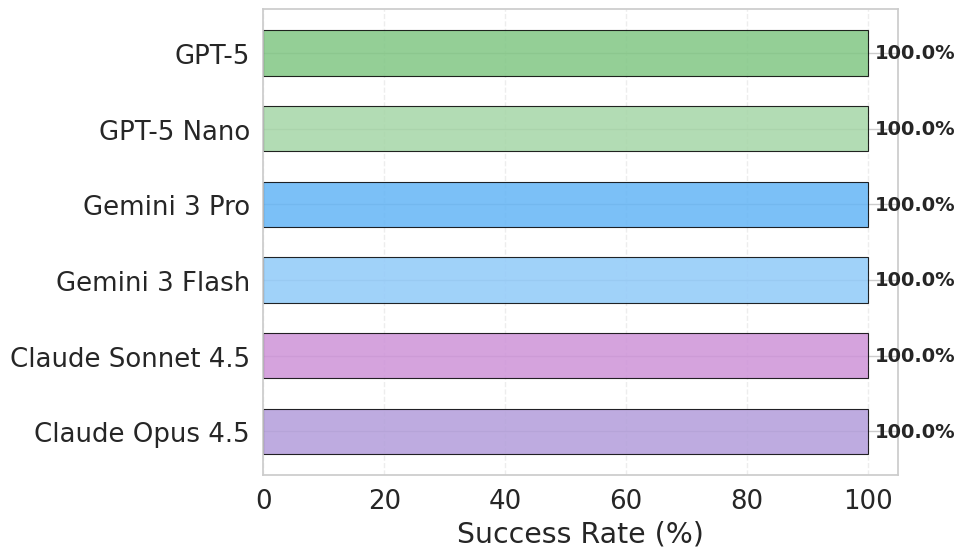


✓ Chart saved to: llm_success_rate.png


In [14]:
# Create horizontal bar chart for success rates
if len(success_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y = np.arange(len(success_stats))
    colors_success = [MODEL_COLORS[m] for m in success_stats.index]
    
    bars = ax.barh(y, success_stats["success_rate"], height=0.6,
                   color=colors_success, edgecolor="black", linewidth=0.8, alpha=0.85)
    
    ax.set_xlabel("Success Rate (%)")
    ax.set_yticks(y)
    ax.set_yticklabels(success_stats.index)
    ax.set_xlim(0, 105)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    
    # Add value labels
    for bar, rate in zip(bars, success_stats["success_rate"]):
        ax.annotate(f"{rate:.1f}%",
                    xy=(rate, bar.get_y() + bar.get_height()/2),
                    xytext=(5, 0), textcoords="offset points",
                    ha="left", va="center", fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("llm_success_rate.png", dpi=300, bbox_inches="tight")
    plt.savefig("llm_success_rate.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("\n✓ Chart saved to: llm_success_rate.png")
else:
    print("Skipping success rate chart - no data available.")

## Plot 6: Cost Comparison by Model

Compare API costs per intent across different LLM providers.

In [15]:
# Calculate cost statistics per model
cost_stats = intent_data.groupby("model_name").agg({
    "cost_total": ["sum", "mean", "std"],
    "cost_input": "sum",
    "cost_output": "sum",
    "intent": "count"
}).round(6)
cost_stats.columns = ["total_cost", "mean_cost", "std_cost", "input_cost", "output_cost", "samples"]

# Convert to cents for readability
cost_stats["cost_per_intent_cents"] = (cost_stats["mean_cost"] * 100).round(4)
cost_stats = cost_stats.reindex([m for m in model_order if m in cost_stats.index])

print("Cost Statistics:")
print("-" * 80)
for model in cost_stats.index:
    row = cost_stats.loc[model]
    print(f"{model:20s}: ${row['total_cost']:.4f} total | "
          f"{row['cost_per_intent_cents']:.4f}¢/intent | "
          f"(${row['input_cost']:.4f} input + ${row['output_cost']:.4f} output)")

Cost Statistics:
--------------------------------------------------------------------------------
Claude Opus 4.5     : $28.8912 total | 28.6052¢/intent | ($27.4236 input + $1.4677 output)
Claude Sonnet 4.5   : $5.7782 total | 5.7210¢/intent | ($5.4847 input + $0.2935 output)
Gemini 3 Flash      : $0.1416 total | 0.1839¢/intent | ($0.0859 input + $0.0558 output)
Gemini 3 Pro        : $2.3915 total | 3.0660¢/intent | ($1.4590 input + $0.9325 output)
GPT-5 Nano          : $0.4629 total | 0.4629¢/intent | ($0.3915 input + $0.0714 output)
GPT-5               : $7.3543 total | 7.3543¢/intent | ($6.7614 input + $0.5929 output)


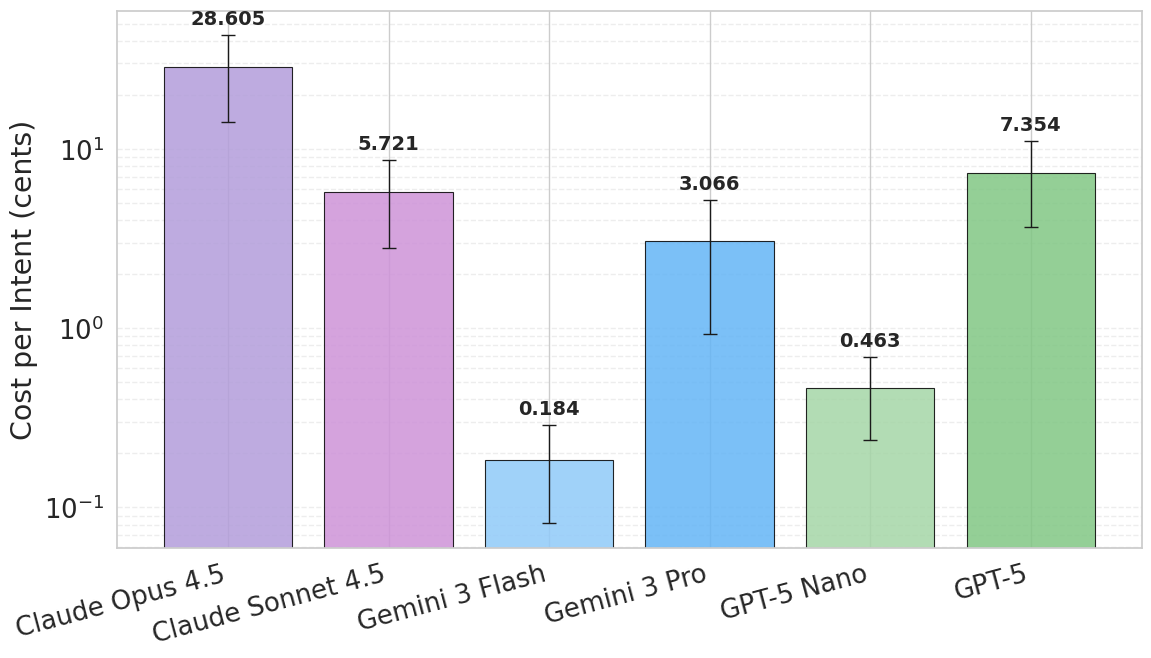


✓ Chart saved to: llm_cost_comparison.png


In [16]:
# Create bar chart for cost per intent
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cost_stats))
colors = [MODEL_COLORS[m] for m in cost_stats.index]

bars = ax.bar(x, cost_stats["cost_per_intent_cents"], color=colors, 
              edgecolor="black", linewidth=0.8, alpha=0.85,
              yerr=cost_stats["std_cost"] * 100, capsize=5,
              error_kw=dict(lw=1, capsize=5, capthick=1))

ax.set_ylabel("Cost per Intent (cents)")
ax.set_xticks(x)
ax.set_xticklabels(cost_stats.index, rotation=15, ha="right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

# Add value labels (positioned above stddev error bars)
for bar, val, std in zip(bars, cost_stats["cost_per_intent_cents"], cost_stats["std_cost"] * 100):
    ax.annotate(f"{val:.3f}",
                xy=(bar.get_x() + bar.get_width()/2, val + std),
                xytext=(0, 5), textcoords="offset points",
                ha="center", va="bottom", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_cost_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_cost_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_cost_comparison.png")

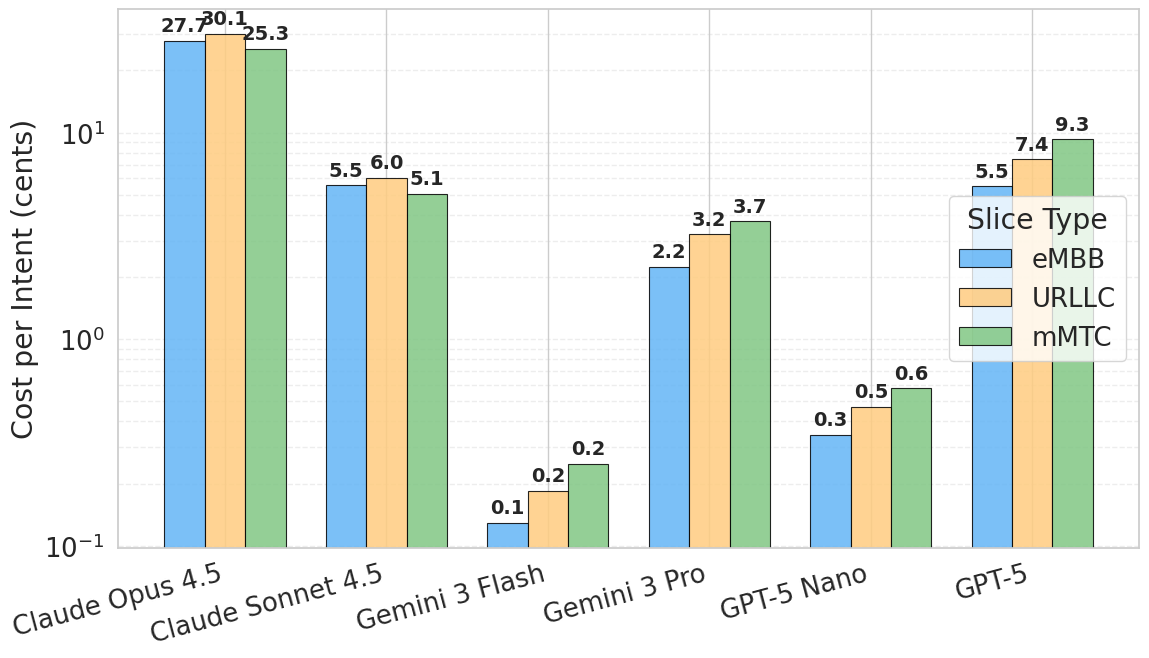


✓ Chart saved to: llm_cost_by_slice_type.png


In [24]:
# Create cost breakdown by slice type
fig, ax = plt.subplots(figsize=(12, 7))

slice_types = ["eMBB", "URLLC", "mMTC"]
slice_colors = {"eMBB": "#64B5F6", "URLLC": "#FFCC80", "mMTC": "#81C784"}

# Calculate cost by model and slice type
cost_by_slice = intent_data.groupby(["model_name", "slice_type"])["cost_total"].mean().unstack(fill_value=0) * 100
cost_by_slice = cost_by_slice.reindex(model_order).dropna(how="all")

x = np.arange(len(cost_by_slice))
width = 0.25

for i, slice_type in enumerate(slice_types):
    if slice_type in cost_by_slice.columns:
        values = cost_by_slice[slice_type].values
        bars = ax.bar(x + i*width, values, width, 
                      label=slice_type, color=slice_colors[slice_type],
                      edgecolor="black", linewidth=0.8, alpha=0.85)
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax.annotate(f"{val:.1f}",
                            xy=(bar.get_x() + bar.get_width()/2, val),
                            xytext=(0, 4), textcoords="offset points",
                            ha="center", va="bottom", fontsize=14, fontweight="bold")

ax.set_ylabel("Cost per Intent (cents)")
ax.set_xticks(x + width)
ax.set_xticklabels(cost_by_slice.index, rotation=15, ha="right")
ax.legend(title="Slice Type", loc="center right")
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", alpha=0.35, which="both")

plt.tight_layout()
plt.savefig("llm_cost_by_slice_type.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_cost_by_slice_type.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_cost_by_slice_type.png")

## Plot 6: Context Growth Analysis

Line chart showing cumulative input tokens across conversation turns.

In [18]:
# Analyze context growth (input tokens grow as conversation progresses)
# Group by model and calculate cumulative stats

context_data = []
for model_name, df in dataframes.items():
    # Sort by index (assuming chronological order)
    df_sorted = df.sort_index().reset_index(drop=True)
    
    # Calculate rolling mean of input tokens (window of 10)
    df_sorted["turn"] = range(1, len(df_sorted) + 1)
    df_sorted["input_tokens_rolling"] = df_sorted["input_tokens"].rolling(window=10, min_periods=1).mean()
    
    context_data.append(df_sorted[["model_name", "turn", "input_tokens", "input_tokens_rolling"]])

context_df = pd.concat(context_data, ignore_index=True)

print("Context Growth Summary:")
print(context_df.groupby("model_name")["input_tokens"].agg(["min", "max", "mean"]).round(0).to_string())

Context Growth Summary:
                   min    max     mean
model_name                            
Claude Opus 4.5    283  38212   9196.0
Claude Sonnet 4.5  283  38212   9196.0
GPT-5              255  52783  13653.0
GPT-5 Nano         255  51421  13375.0
Gemini 3 Flash     255  29162   8126.0
Gemini 3 Pro       254  29162   7613.0


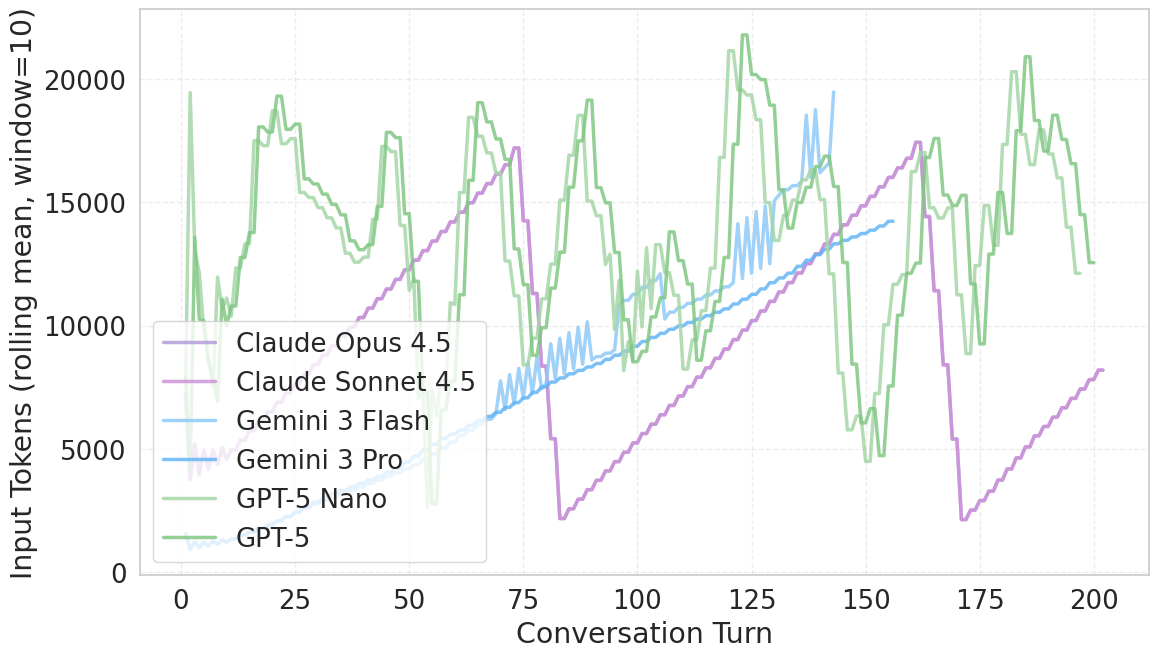


✓ Chart saved to: llm_context_growth.png


In [30]:
# Create line chart for context growth
fig, ax = plt.subplots(figsize=(12, 7))

for model_name in model_order:
    if model_name in context_df["model_name"].unique():
        model_data = context_df[context_df["model_name"] == model_name]
        ax.plot(model_data["turn"], model_data["input_tokens_rolling"], 
                label=model_name, color=MODEL_COLORS[model_name], 
                linewidth=2.5, alpha=0.85)

ax.set_xlabel("Conversation Turn")
ax.set_ylabel("Input Tokens (rolling mean, window=10)")
ax.legend(loc="lower left")
ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("llm_context_growth.png", dpi=300, bbox_inches="tight")
plt.savefig("llm_context_growth.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\n✓ Chart saved to: llm_context_growth.png")

## Summary Statistics Table

In [20]:
# Create comprehensive summary table
print("=" * 100)
print("LLM PERFORMANCE SUMMARY")
print("=" * 100)

summary_table = intent_data.groupby("model_name").agg({
    "intent": "count",
    "input_tokens": ["mean", "std"],
    "output_tokens": ["mean", "std"],
    "reasoning_tokens": "mean",
}).round(1)

summary_table.columns = ["Samples", "Input (mean)", "Input (std)", 
                         "Output (mean)", "Output (std)", "Reasoning (mean)"]

# Add latency if available
if "latency_seconds" in intent_data.columns:
    latency_mean = intent_data.groupby("model_name")["latency_seconds"].mean().round(2)
    summary_table["Latency (s)"] = latency_mean

# Add success rate if available
if len(success_data) > 0:
    summary_table["Success (%)"] = success_stats["success_rate"]

# Add cost per intent (in cents for readability)
if "cost_total" in intent_data.columns:
    cost_per_intent = intent_data.groupby("model_name")["cost_total"].mean() * 100  # cents
    summary_table["Cost (¢/intent)"] = cost_per_intent.round(4)

# Reorder
summary_table = summary_table.reindex([m for m in model_order if m in summary_table.index])

print(summary_table.to_string())
print("=" * 100)

LLM PERFORMANCE SUMMARY
                   Samples  Input (mean)  Input (std)  Output (mean)  Output (std)  Reasoning (mean)  Latency (s)  Success (%)  Cost (¢/intent)
model_name                                                                                                                                     
Claude Opus 4.5        101       18101.4       9501.6          193.8         112.0               0.0          NaN        100.0          28.6052
Claude Sonnet 4.5      101       18101.4       9501.6          193.8         112.0               0.0          NaN        100.0           5.7210
Gemini 3 Flash          77       14865.9       8347.4         2415.2        2028.3            5015.2          NaN        100.0           0.1839
Gemini 3 Pro            78       14963.9       8175.2         2391.0        2786.8            4159.6          NaN        100.0           3.0660
GPT-5 Nano             100       26096.7      14791.2         1190.7         375.8            1107.8        10.5